In [11]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from cnn_model_24to1 import CNN, cross_validate, train
import torch
import torch.nn as nn
import random
import os, sys

# load data through the data preprocessor
sys.path.append(os.path.abspath('..'))  # add parent directory to sys.path
from data_cleanup import DataProcessor

# Reproducibility (best-effort)
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

## Data Preprocessing

In [12]:
# Instantiate DataProcessor for 24h -> 1h
INPUT_STEPS = 24  # 24 hours
OUTPUT_STEPS = 1  # 1 hour
processor = DataProcessor(input_steps=INPUT_STEPS, output_steps=OUTPUT_STEPS, local_raw_path='../raw-consumption-data.zip')

# This will fetch, clean, resample and window the data (may take a moment)
(X_train, y_train), (X_val, y_val), (X_test, y_test) = processor.load_and_process_data()

print('Shapes:')
print('X_train', X_train.shape, 'y_train', y_train.shape)
print('X_val', X_val.shape, 'y_val', y_val.shape)
print('X_test', X_test.shape, 'y_test', y_test.shape)

Step 1/5: Fetching, cleaning, and engineering features...


e:\ywc_college\junior1\notebook\Machine Learning\pj\ECS171G13\data_cleanup.py:132: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
e:\ywc_college\junior1\notebook\Machine Learning\pj\ECS171G13\data_cleanup.py:172: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').agg(agg_dict)


Step 2/5: Resampling data to hourly and setting 'Global_active_power' as target...
Step 3/5: Splitting data and applying scaler...
Step 4/5: Creating time-series windows...
Step 5/5: Data processing complete.
Shapes:
X_train (25903, 24, 8) y_train (25903, 1)
X_val (3600, 24, 8) y_val (3600, 1)
X_test (5014, 24, 8) y_test (5014, 1)
Step 3/5: Splitting data and applying scaler...
Step 4/5: Creating time-series windows...
Step 5/5: Data processing complete.
Shapes:
X_train (25903, 24, 8) y_train (25903, 1)
X_val (3600, 24, 8) y_val (3600, 1)
X_test (5014, 24, 8) y_test (5014, 1)


e:\ywc_college\junior1\notebook\Machine Learning\pj\ECS171G13\data_cleanup.py:173: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_hourly = df_hourly.fillna(method='ffill')


In [13]:
# Select the 4 sub-metering channels as input channels
# Based on data_cleanup.py ordering, expected columns after reorder are:
# [Global_active_power, Global_reactive_power, Voltage, Global_intensity,
#  Sub_metering_1, Sub_metering_2, Sub_metering_3, Sub_metering_rest]
# So sub-metering channel indices (0-based) are 4..7
channel_indices = [4,5,6,7]
n_features = X_train.shape[2]
assert max(channel_indices) < n_features, 'Channel indices out of range for X_train features'

X_train_ch = X_train[:, :, channel_indices]  # shape (n_samples, time, 4)
X_val_ch   = X_val[:, :, channel_indices]
X_test_ch  = X_test[:, :, channel_indices]

print('Selected channel shapes:')
print('X_train_ch', X_train_ch.shape, 'y_train', y_train.shape)

Selected channel shapes:
X_train_ch (25903, 24, 4) y_train (25903, 1)


In [14]:
# Create TimeSeriesSplit folds from the training windows (time-aware)
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
folds = []
for train_idx, val_idx in tscv.split(X_train_ch):
    Xtr = X_train_ch[train_idx]
    ytr = y_train[train_idx]
    Xval = X_train_ch[val_idx]
    yval = y_train[val_idx]
    folds.append(((Xtr, ytr), (Xval, yval)))

print(f'Constructed {len(folds)} folds. Example fold shapes:')
print('fold0 train X', folds[0][0][0].shape, 'y', folds[0][0][1].shape, 'val X', folds[0][1][0].shape)

Constructed 5 folds. Example fold shapes:
fold0 train X (4318, 24, 4) y (4318, 1) val X (4317, 24, 4)


## Model Training

In [15]:
# Define model factory (callable returning a fresh model)
def make_model():
    return CNN(in_channels=4, input_length=INPUT_STEPS, output_steps=OUTPUT_STEPS)

### A demo for cross-validation training

In [16]:
# Run cross-validation quickly (small epochs for demo) WITH checkpoint saving
histories, val_losses, best_cv_checkpoint_path = cross_validate(
    make_model,
    folds,
    device=None,
    epochs=3,
    batch_size=32,
    lr=1e-3,
    verbose=True,
    checkpoint_dir='checkpoint/cv_24to1_demo',
    save_best_only=True
)
print('Per-fold final val losses:', val_losses)
print('Best CV checkpoint path:', best_cv_checkpoint_path)
print('Best per-fold checkpoint directories saved under: checkpoint/cv_24to1_demo/')

Starting fold 1/5: train (4318, 24, 4) | val (4317, 24, 4)
Epoch 1/3 - train_loss: 0.022190 - val_loss: 0.012552
Epoch 1/3 - train_loss: 0.022190 - val_loss: 0.012552
Epoch 2/3 - train_loss: 0.011714 - val_loss: 0.009710
Epoch 2/3 - train_loss: 0.011714 - val_loss: 0.009710
Epoch 3/3 - train_loss: 0.010433 - val_loss: 0.009202
Starting fold 2/5: train (8635, 24, 4) | val (4317, 24, 4)
Epoch 3/3 - train_loss: 0.010433 - val_loss: 0.009202
Starting fold 2/5: train (8635, 24, 4) | val (4317, 24, 4)
Epoch 1/3 - train_loss: 0.016742 - val_loss: 0.011091
Epoch 1/3 - train_loss: 0.016742 - val_loss: 0.011091
Epoch 2/3 - train_loss: 0.009644 - val_loss: 0.009926
Epoch 2/3 - train_loss: 0.009644 - val_loss: 0.009926
Epoch 3/3 - train_loss: 0.009025 - val_loss: 0.009622
Starting fold 3/5: train (12952, 24, 4) | val (4317, 24, 4)
Epoch 3/3 - train_loss: 0.009025 - val_loss: 0.009622
Starting fold 3/5: train (12952, 24, 4) | val (4317, 24, 4)
Epoch 1/3 - train_loss: 0.014368 - val_loss: 0.007850
E

### Plain training & testing

In [17]:
# Final full training on all training windows + validation, save best checkpoint
import os
os.makedirs('checkpoint/run1_24to1', exist_ok=True)
final_hist = train(
    make_model(),
    X_train_ch,
    y_train,
    X_val=X_val_ch,
    y_val=y_val,
    device=None,
    epochs=10,
    batch_size=32,
    lr=1e-3,
    verbose=True,
    checkpoint_dir='checkpoint/run1_24to1',
    checkpoint_prefix='final',
    save_best_only=True
)
print('Final training best val loss:', final_hist['best_val_loss'])
print('Best checkpoint path:', final_hist['checkpoint_path'])

Epoch 1/10 - train_loss: 0.011579 - val_loss: 0.007921
Epoch 2/10 - train_loss: 0.007940 - val_loss: 0.007667
Epoch 2/10 - train_loss: 0.007940 - val_loss: 0.007667
Epoch 3/10 - train_loss: 0.007617 - val_loss: 0.007778
Epoch 3/10 - train_loss: 0.007617 - val_loss: 0.007778
Epoch 4/10 - train_loss: 0.007417 - val_loss: 0.007703
Epoch 4/10 - train_loss: 0.007417 - val_loss: 0.007703
Epoch 5/10 - train_loss: 0.007255 - val_loss: 0.007274
Epoch 5/10 - train_loss: 0.007255 - val_loss: 0.007274
Epoch 6/10 - train_loss: 0.007076 - val_loss: 0.007011
Epoch 6/10 - train_loss: 0.007076 - val_loss: 0.007011
Epoch 7/10 - train_loss: 0.006912 - val_loss: 0.006828
Epoch 7/10 - train_loss: 0.006912 - val_loss: 0.006828
Epoch 8/10 - train_loss: 0.006744 - val_loss: 0.006853
Epoch 8/10 - train_loss: 0.006744 - val_loss: 0.006853
Epoch 9/10 - train_loss: 0.006542 - val_loss: 0.006931
Epoch 9/10 - train_loss: 0.006542 - val_loss: 0.006931
Epoch 10/10 - train_loss: 0.006380 - val_loss: 0.006977
Final tra

In [18]:
# Load best model for test evaluation
best_model = make_model()
if final_hist['checkpoint_path']:
    ckpt = torch.load(final_hist['checkpoint_path'], map_location='cpu')
    best_model.load_state_dict(ckpt['model_state_dict'])

# Evaluate on test set (ensure tensor shapes and device)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_model = best_model.to(device)
best_model.eval()

with torch.no_grad():
    Xt = torch.tensor(X_test_ch, dtype=torch.float32).to(device)
    if Xt.ndim == 3 and Xt.shape[2] == 4 and Xt.shape[1] != 4:
        Xt = Xt.permute(0, 2, 1)
    preds = best_model(Xt)
    yt = torch.tensor(y_test, dtype=torch.float32).to(device)
    preds_np = preds.cpu().numpy()
    yt_np = yt.cpu().numpy()

# Inverse-transform predictions back to original units using the processor's scaler
preds_un = np.zeros_like(preds_np)
yt_un = np.zeros_like(yt_np)

# For single-step output, handle as 1D array
if preds_np.ndim == 2 and preds_np.shape[1] == 1:
    # Flatten to (n_samples,)
    preds_flat = preds_np.squeeze()
    yt_flat = yt_np.squeeze()
    try:
        preds_un_flat = processor.inverse_transform_predictions(preds_flat)
        yt_un_flat = processor.inverse_transform_predictions(yt_flat)
        preds_un = preds_un_flat.reshape(-1, 1)
        yt_un = yt_un_flat.reshape(-1, 1)
    except Exception as e:
        print('Warning: inverse transform failed -> plotting scaled values. Error:', e)
        preds_un = preds_np
        yt_un = yt_np
else:
    preds_un = preds_np
    yt_un = yt_np

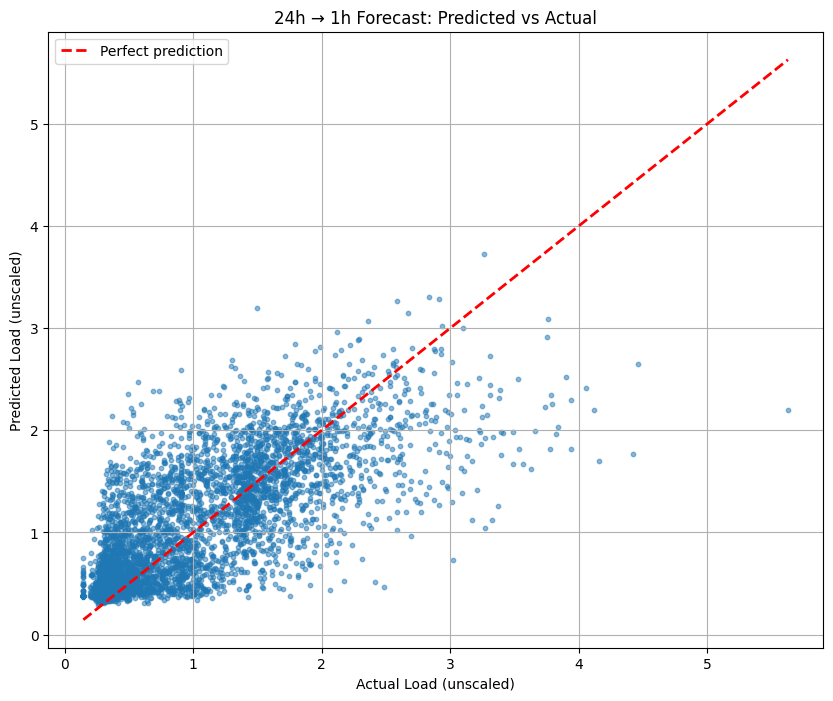

Final test MSE (unscaled): 0.230607
Final test MAE (unscaled): 0.342250


In [19]:
# Plot scatter plot for predicted vs actual (single-step forecasting)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(yt_un, preds_un, alpha=0.5, s=10)
plt.plot([yt_un.min(), yt_un.max()], [yt_un.min(), yt_un.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Load (unscaled)')
plt.ylabel('Predicted Load (unscaled)')
plt.title('24h → 1h Forecast: Predicted vs Actual')
plt.legend()
plt.grid(True)
plt.show()

# Numeric summary (unscaled MSE and MAE)
mse_unscaled = np.mean((preds_un - yt_un)**2)
mae_unscaled = np.mean(np.abs(preds_un - yt_un))
print(f'Final test MSE (unscaled): {mse_unscaled:.6f}')
print(f'Final test MAE (unscaled): {mae_unscaled:.6f}')

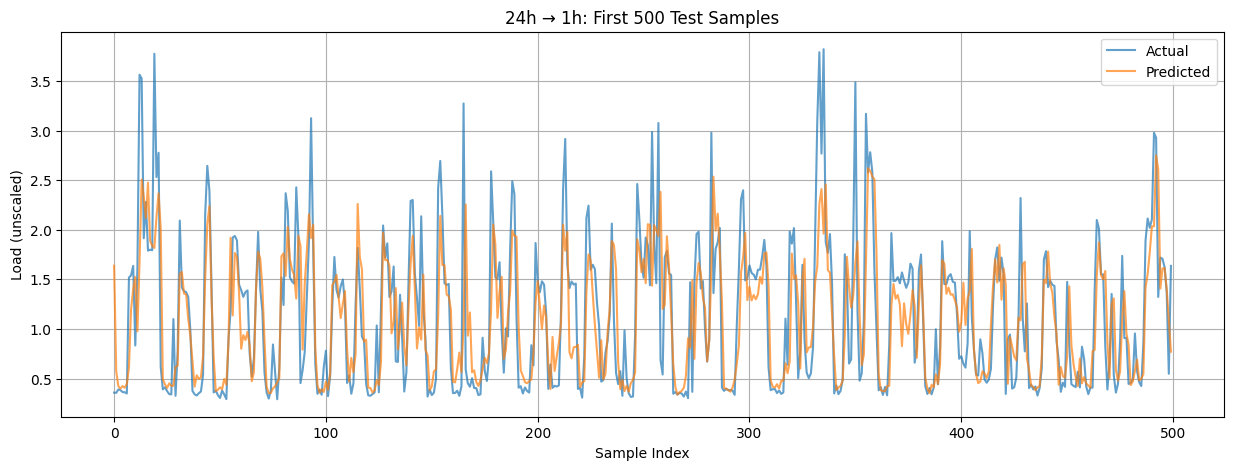

In [20]:
# Plot time series of first 500 predictions
n_samples = min(500, len(preds_un))
plt.figure(figsize=(15, 5))
plt.plot(range(n_samples), yt_un[:n_samples], label='Actual', alpha=0.7)
plt.plot(range(n_samples), preds_un[:n_samples], label='Predicted', alpha=0.7)
plt.xlabel('Sample Index')
plt.ylabel('Load (unscaled)')
plt.title('24h → 1h: First 500 Test Samples')
plt.legend()
plt.grid(True)
plt.show()

Notes:
- This demo uses small epoch counts so it runs quickly; increase epochs for serious training.
- The model predicts only 1 hour ahead, making it suitable for very short-term forecasting.
- If your DataProcessor used different column ordering or unit scaling, adjust `channel_indices`.

## Cross-Validation Training and Testing

Starting fold 1/5: train (4318, 24, 4) | val (4317, 24, 4)
Epoch 1/20 - train_loss: 0.022782 - val_loss: 0.013749
Epoch 1/20 - train_loss: 0.022782 - val_loss: 0.013749
Epoch 2/20 - train_loss: 0.013436 - val_loss: 0.010418
Epoch 2/20 - train_loss: 0.013436 - val_loss: 0.010418
Epoch 3/20 - train_loss: 0.011192 - val_loss: 0.009429
Epoch 3/20 - train_loss: 0.011192 - val_loss: 0.009429
Epoch 4/20 - train_loss: 0.010077 - val_loss: 0.009209
Epoch 4/20 - train_loss: 0.010077 - val_loss: 0.009209
Epoch 5/20 - train_loss: 0.009606 - val_loss: 0.009027
Epoch 5/20 - train_loss: 0.009606 - val_loss: 0.009027
Epoch 6/20 - train_loss: 0.009189 - val_loss: 0.008948
Epoch 6/20 - train_loss: 0.009189 - val_loss: 0.008948
Epoch 7/20 - train_loss: 0.009007 - val_loss: 0.008987
Epoch 7/20 - train_loss: 0.009007 - val_loss: 0.008987
Epoch 8/20 - train_loss: 0.008744 - val_loss: 0.009126
Epoch 8/20 - train_loss: 0.008744 - val_loss: 0.009126
Epoch 9/20 - train_loss: 0.008505 - val_loss: 0.009059
Epoch 

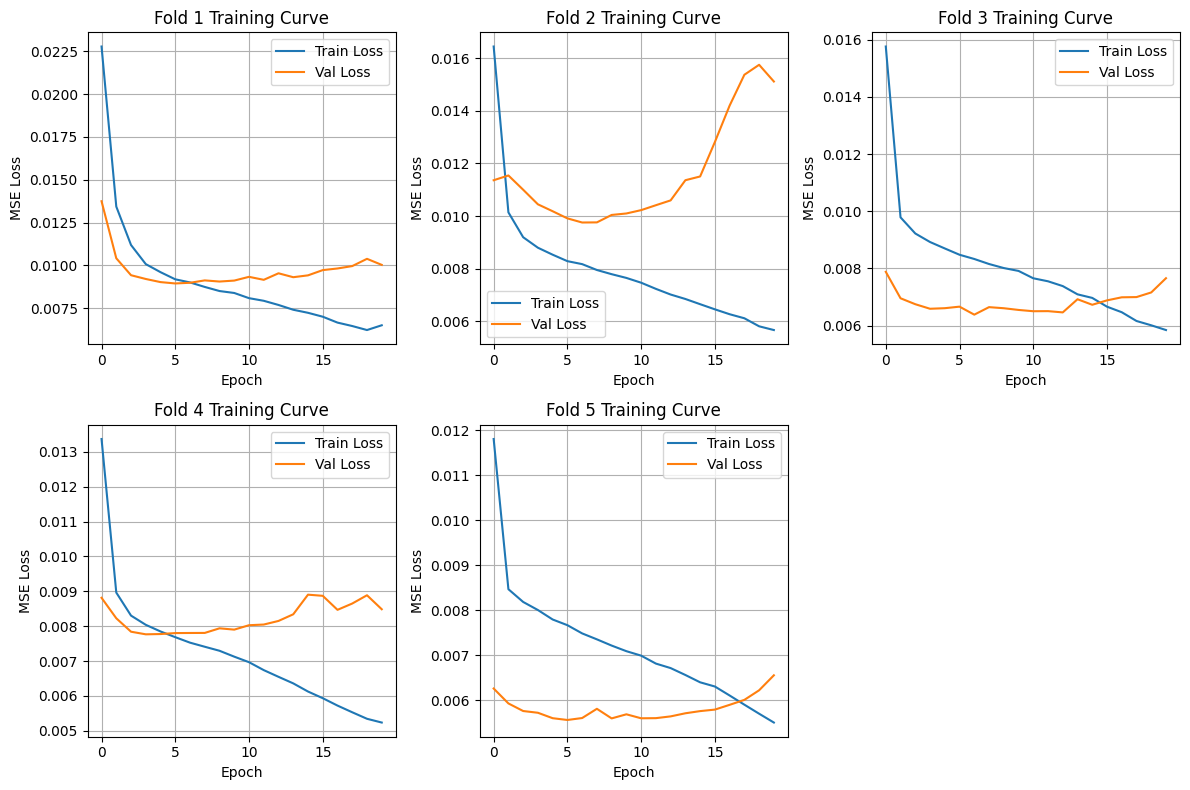

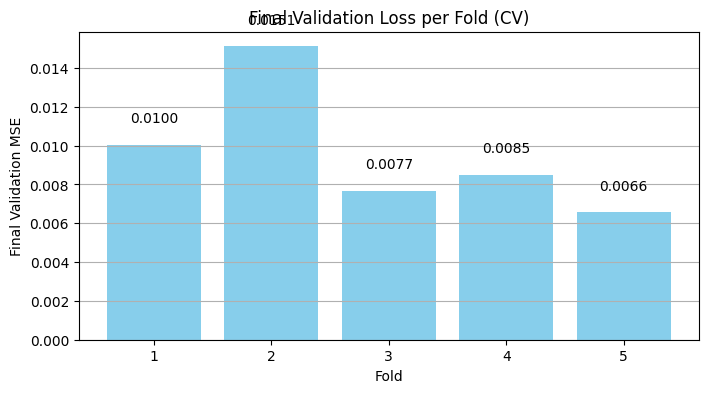

In [21]:
# Final Cross-Validation Training (Higher Epochs)
import numpy as np, torch, matplotlib.pyplot as plt, json, os

# Set final epochs for CV training
FINAL_CV_EPOCHS = 20  # Increase for better training

# Run cross-validation with higher epochs
cv_histories, cv_val_losses, cv_best_checkpoint = cross_validate(
    make_model,
    folds,
    device=None,
    epochs=FINAL_CV_EPOCHS,
    batch_size=32,
    lr=1e-3,
    verbose=True,
    checkpoint_dir='checkpoint/final_cv_24to1',
    save_best_only=True
)

print('CV Final val losses per fold:', cv_val_losses)
print('Best CV checkpoint:', cv_best_checkpoint)

# Plot training curves for all folds
plt.figure(figsize=(12, 8))
for i, hist in enumerate(cv_histories, start=1):
    plt.subplot(2, 3, i)
    plt.plot(hist['train_loss'], label='Train Loss')
    if 'val_loss' in hist:
        plt.plot(hist['val_loss'], label='Val Loss')
    plt.title(f'Fold {i} Training Curve')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

# Bar chart of final val losses
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(cv_val_losses) + 1), cv_val_losses, color='skyblue')
plt.xlabel('Fold')
plt.ylabel('Final Validation MSE')
plt.title('Final Validation Loss per Fold (CV)')
plt.xticks(range(1, len(cv_val_losses) + 1))
for i, v in enumerate(cv_val_losses, start=1):
    plt.text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom')
plt.grid(axis='y')
plt.show()

Loaded CV model from checkpoint/final_cv_24to1\fold_5\fold5_best.pt


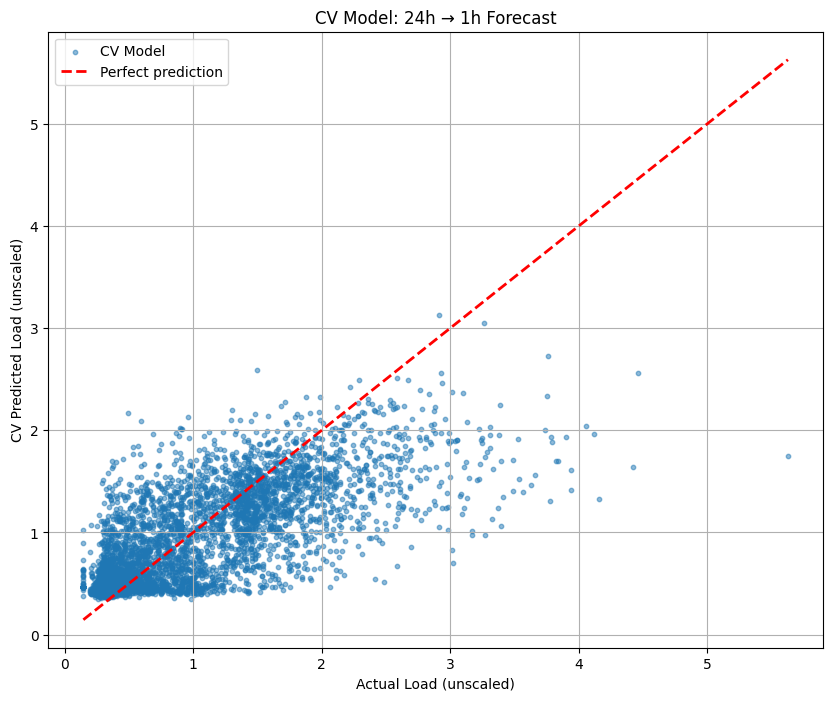

CV Model Test MSE: 0.224988
CV Model Test MAE: 0.328006


In [22]:
# Load and Evaluate Best CV Model for Visualization
cv_model = make_model()
if cv_best_checkpoint and os.path.isfile(cv_best_checkpoint):
    ckpt = torch.load(cv_best_checkpoint, map_location='cpu')
    cv_model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded CV model from {cv_best_checkpoint}')
else:
    print('CV checkpoint not found')

# Evaluate on test set
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cv_model = cv_model.to(device)
cv_model.eval()

with torch.no_grad():
    Xt = torch.tensor(X_test_ch, dtype=torch.float32).to(device)
    if Xt.ndim == 3 and Xt.shape[2] == 4 and Xt.shape[1] != 4:
        Xt = Xt.permute(0, 2, 1)
    cv_preds = cv_model(Xt)
    yt = torch.tensor(y_test, dtype=torch.float32).to(device)
    cv_preds_np = cv_preds.cpu().numpy()
    yt_np = yt.cpu().numpy()

# Inverse transform
cv_preds_un = np.zeros_like(cv_preds_np)
yt_un = np.zeros_like(yt_np)
if cv_preds_np.ndim == 2 and cv_preds_np.shape[1] == 1:
    cv_preds_flat = cv_preds_np.squeeze()
    yt_flat = yt_np.squeeze()
    try:
        cv_preds_un_flat = processor.inverse_transform_predictions(cv_preds_flat)
        yt_un_flat = processor.inverse_transform_predictions(yt_flat)
        cv_preds_un = cv_preds_un_flat.reshape(-1, 1)
        yt_un = yt_un_flat.reshape(-1, 1)
    except:
        cv_preds_un = cv_preds_np
        yt_un = yt_np
else:
    cv_preds_un = cv_preds_np
    yt_un = yt_np

# Scatter plot visualization
plt.figure(figsize=(10, 8))
plt.scatter(yt_un, cv_preds_un, alpha=0.5, s=10, label='CV Model')
plt.plot([yt_un.min(), yt_un.max()], [yt_un.min(), yt_un.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Load (unscaled)')
plt.ylabel('CV Predicted Load (unscaled)')
plt.title('CV Model: 24h → 1h Forecast')
plt.legend()
plt.grid(True)
plt.show()

# Overall MSE
cv_mse = np.mean((cv_preds_un - yt_un)**2)
cv_mae = np.mean(np.abs(cv_preds_un - yt_un))
print(f'CV Model Test MSE: {cv_mse:.6f}')
print(f'CV Model Test MAE: {cv_mae:.6f}')

Loaded Plain model from checkpoint/run1_24to1/final_best.pt
Metrics Comparison (Normalized):
CV - MSE: 0.005431, MAE: 0.050960, SMAPE: 0.4688
Plain - MSE: 0.005566, MAE: 0.053173, SMAPE: 0.4693


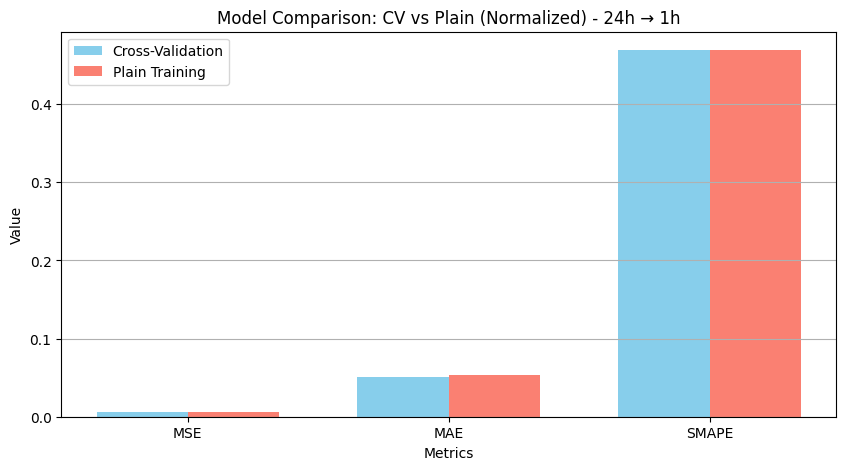

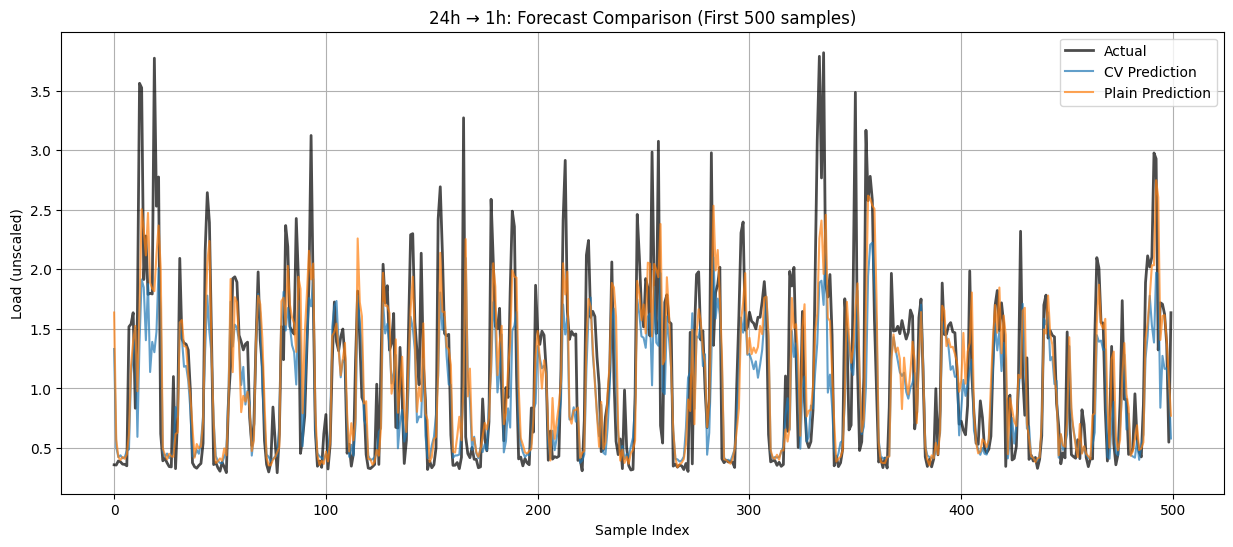

Comparison saved to model_comparison_24to1.json


In [23]:
# Comparison Analysis: Plain vs Cross-Validation
import json

# Load Plain model (from earlier training)
plain_checkpoint = 'checkpoint/run1_24to1/final_best.pt'  # Assuming this is the path
plain_model = make_model()
if os.path.isfile(plain_checkpoint):
    ckpt = torch.load(plain_checkpoint, map_location='cpu')
    plain_model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded Plain model from {plain_checkpoint}')
else:
    print('Plain checkpoint not found')

# Evaluate Plain model
plain_model = plain_model.to(device)
plain_model.eval()
with torch.no_grad():
    plain_preds = plain_model(Xt)  # Xt already defined
    plain_preds_np = plain_preds.cpu().numpy()

# Inverse transform plain predictions
plain_preds_un = np.zeros_like(plain_preds_np)
if plain_preds_np.ndim == 2 and plain_preds_np.shape[1] == 1:
    plain_preds_flat = plain_preds_np.squeeze()
    try:
        plain_preds_un_flat = processor.inverse_transform_predictions(plain_preds_flat)
        plain_preds_un = plain_preds_un_flat.reshape(-1, 1)
    except:
        plain_preds_un = plain_preds_np
else:
    plain_preds_un = plain_preds_np

# Metrics comparison using normalized (scaled) data
def compute_metrics(preds_scaled, actuals_scaled):
    err = preds_scaled - actuals_scaled
    mse = float(np.mean(err**2))
    mae = float(np.mean(np.abs(err)))
    mape = float(np.mean(np.abs(err) / (np.abs(actuals_scaled) + 1e-8)))
    smape = float(np.mean(2 * np.abs(err) / (np.abs(preds_scaled) + np.abs(actuals_scaled) + 1e-8)))
    return {'MSE': mse, 'MAE': mae, 'MAPE': mape, 'SMAPE': smape}

cv_metrics = compute_metrics(cv_preds_np, yt_np)  # Use scaled data
plain_metrics = compute_metrics(plain_preds_np, yt_np)

print('Metrics Comparison (Normalized):')
print(f"CV - MSE: {cv_metrics['MSE']:.6f}, MAE: {cv_metrics['MAE']:.6f}, SMAPE: {cv_metrics['SMAPE']:.4f}")
print(f"Plain - MSE: {plain_metrics['MSE']:.6f}, MAE: {plain_metrics['MAE']:.6f}, SMAPE: {plain_metrics['SMAPE']:.4f}")

# Bar chart comparison
labels = ['MSE', 'MAE', 'SMAPE']
cv_vals = [cv_metrics['MSE'], cv_metrics['MAE'], cv_metrics['SMAPE']]
plain_vals = [plain_metrics['MSE'], plain_metrics['MAE'], plain_metrics['SMAPE']]

x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(10, 5))
plt.bar(x - width/2, cv_vals, width, label='Cross-Validation', color='skyblue')
plt.bar(x + width/2, plain_vals, width, label='Plain Training', color='salmon')
plt.xlabel('Metrics')
plt.ylabel('Value')
plt.title('Model Comparison: CV vs Plain (Normalized) - 24h → 1h')
plt.xticks(x, labels)
plt.legend()
plt.grid(axis='y')
plt.show()

# Overlaid time series comparison
n_samples = min(500, len(cv_preds_un))
plt.figure(figsize=(15, 6))
plt.plot(range(n_samples), yt_un[:n_samples], label='Actual', linewidth=2, color='black', alpha=0.7)
plt.plot(range(n_samples), cv_preds_un[:n_samples], label='CV Prediction', linewidth=1.5, alpha=0.7)
plt.plot(range(n_samples), plain_preds_un[:n_samples], label='Plain Prediction', linewidth=1.5, alpha=0.7)
plt.title('24h → 1h: Forecast Comparison (First 500 samples)')
plt.xlabel('Sample Index')
plt.ylabel('Load (unscaled)')
plt.legend()
plt.grid(True)
plt.show()

# Save comparison results (convert to JSON serializable)
comparison = {
    'cv': cv_metrics,
    'plain': plain_metrics,
    'cv_checkpoint': cv_best_checkpoint,
    'plain_checkpoint': plain_checkpoint
}
with open('model_comparison_24to1.json', 'w') as f:
    json.dump(comparison, f, indent=2)
print('Comparison saved to model_comparison_24to1.json')